In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [5]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/r2000_a20')]

In [6]:
scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name,'input')
output_path = os.path.join(root_output_directory, scenario_name,'output')
post_path = os.path.join(root_output_directory, scenario_name,'post')

In [7]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))

In [8]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation','g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0','jackson_root_beta']

In [23]:
df.sort_values(by=['RMSE_MAX'],inplace=True, ascending=True)
df = df[df['RMSE_MAX']< 1.2]
df_grp = df.groupby(['id'])[vars].mean()

In [24]:
for var in vars:
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    ax.hist(df_grp[var], alpha=1.0, bins = 20)
    ax.set_xlabel(var)
    plt.savefig(f"{post_path}/mean_hist_{var}.png")
    plt.close(fig)

In [26]:
df.loc[df.index[0:5].sort_values()]

,Unnamed: 0,index,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
1400,0,165,280,1800.0,1800,False,1.0,4.0,Weibull,1.051199,...,0.396200,0.268685,0.423980,0.405213,0.464015,0.412135,0.414612,0.922946,0.979317,0
1401,1,629,280,1800.0,1800,False,1.0,4.0,Weibull,0.837368,...,3.842482,7.964345,3.935754,4.168693,3.937962,3.859592,4.556043,0.922946,0.979317,1
1402,2,329,280,1800.0,1800,False,1.0,4.0,Weibull,1.065280,...,1.697610,1.907954,1.046576,1.170581,1.005244,0.952645,1.197508,0.922946,0.979317,2
1403,3,692,280,1800.0,1800,False,1.0,4.0,Weibull,1.161407,...,18.653092,18.841387,10.382210,10.842681,10.365130,10.256820,11.646988,0.922946,0.979317,3
1404,4,1790,280,1800.0,1800,False,1.0,4.0,Weibull,1.158962,...,19.464958,19.653746,11.919096,12.476999,11.895766,11.880510,13.118525,0.922946,0.979317,4


(array([  5.,  60., 140., 230., 335., 380., 165., 125.,  60.,  55.]),
 array([0.97931723, 1.04515711, 1.11099699, 1.17683688, 1.24267676,
        1.30851664, 1.37435652, 1.44019641, 1.50603629, 1.57187617,
        1.63771605]),
 <BarContainer object of 10 artists>)

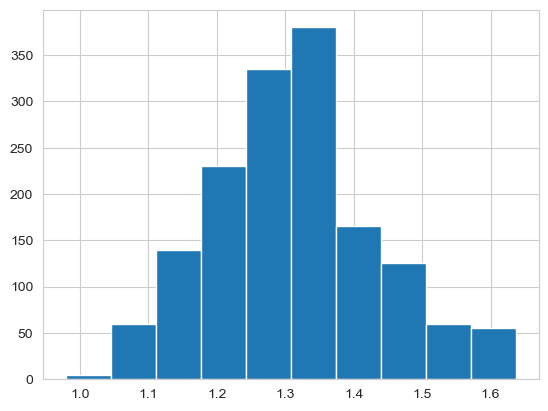

In [11]:
plt.hist(df['RMSE_MAX'])

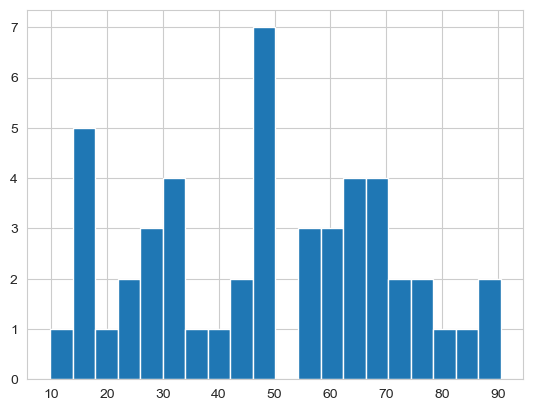

In [22]:
plt.hist(df_grp[vars[3]], bins =20 );

In [14]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [15]:
df_grp

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
id,,,,,,,,,,,,,,,,,
4,-2.052091,4.073147,5945.812039,47.788049,0.000786,0.117766,-3.791964,0.002793,1.073268,1.673889e-06,-2.751143,0.911151,0.270624,1.202767,5.769214,-0.324386,0.008683
10,-2.037814,3.408322,6055.668087,59.764447,0.000854,0.105969,-3.940256,0.002877,1.096324,1.634552e-06,-2.984962,0.917070,0.280285,1.064105,10.915995,-0.426945,0.010003
14,-2.082267,4.003427,5834.501101,56.187232,0.000834,0.075626,-3.955350,0.002459,0.986114,9.564518e-07,-2.502996,0.938606,0.269719,0.929025,8.401467,-0.391080,0.009472
17,-2.054254,3.833720,4071.216050,33.136378,0.000914,0.268844,-3.993018,0.002505,0.964905,6.593124e-07,-2.463412,0.927263,0.278924,1.226195,8.912240,-0.501641,0.007322
20,-2.218488,4.322408,4737.661024,70.381908,0.000801,0.608068,-3.937377,0.002401,0.905858,7.577229e-07,-2.651661,0.930901,0.277381,1.008600,5.051167,-0.257980,0.008555
23,-2.070219,2.901331,5562.901130,87.821285,0.000848,0.208622,-3.882009,0.002969,1.009117,4.124871e-07,-2.530020,0.920025,0.276882,1.296016,8.920372,-0.283179,0.011213
38,-2.028726,3.209695,5165.239259,9.747859,0.000843,0.177915,-3.932968,0.002208,1.050303,4.190807e-07,-2.864321,0.942004,0.264571,1.196580,10.590701,-0.249193,0.007834
43,-2.093677,2.886978,5905.882873,42.009063,0.000758,0.166617,-3.838414,0.002502,1.014091,6.578417e-07,-3.091478,0.925867,0.273426,0.977384,12.026321,-0.427167,0.007745
47,-2.037631,3.431138,5416.398343,24.097201,0.000808,0.377578,-4.007380,0.002959,0.936446,1.367364e-06,-2.766965,0.921827,0.261561,1.269250,9.020452,-0.046444,0.009745


In [16]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(df_grp)

KMeans(n_clusters=3, random_state=0)

<Axes: >

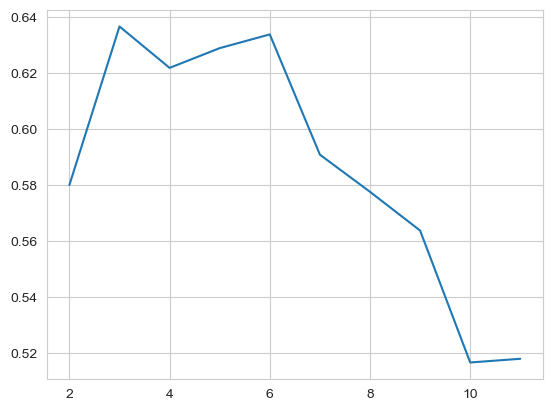

In [17]:
K = range(2, 12)
fits = []
score = []

for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(df_grp)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(df_grp, model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

In [19]:
nclusters = 8
kmeans = KMeans(n_clusters = nclusters, random_state = 0, n_init='auto')
kmeans.fit(df_grp)
cvals  = [0.0,  1]
colors = ["red","tab:blue"]
alive_means = [df_grp.loc[kmeans.labels_ == i, 'alive'].mean() for i in range(nclusters)]

norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
import matplotlib.colors
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

KeyError: 'alive'

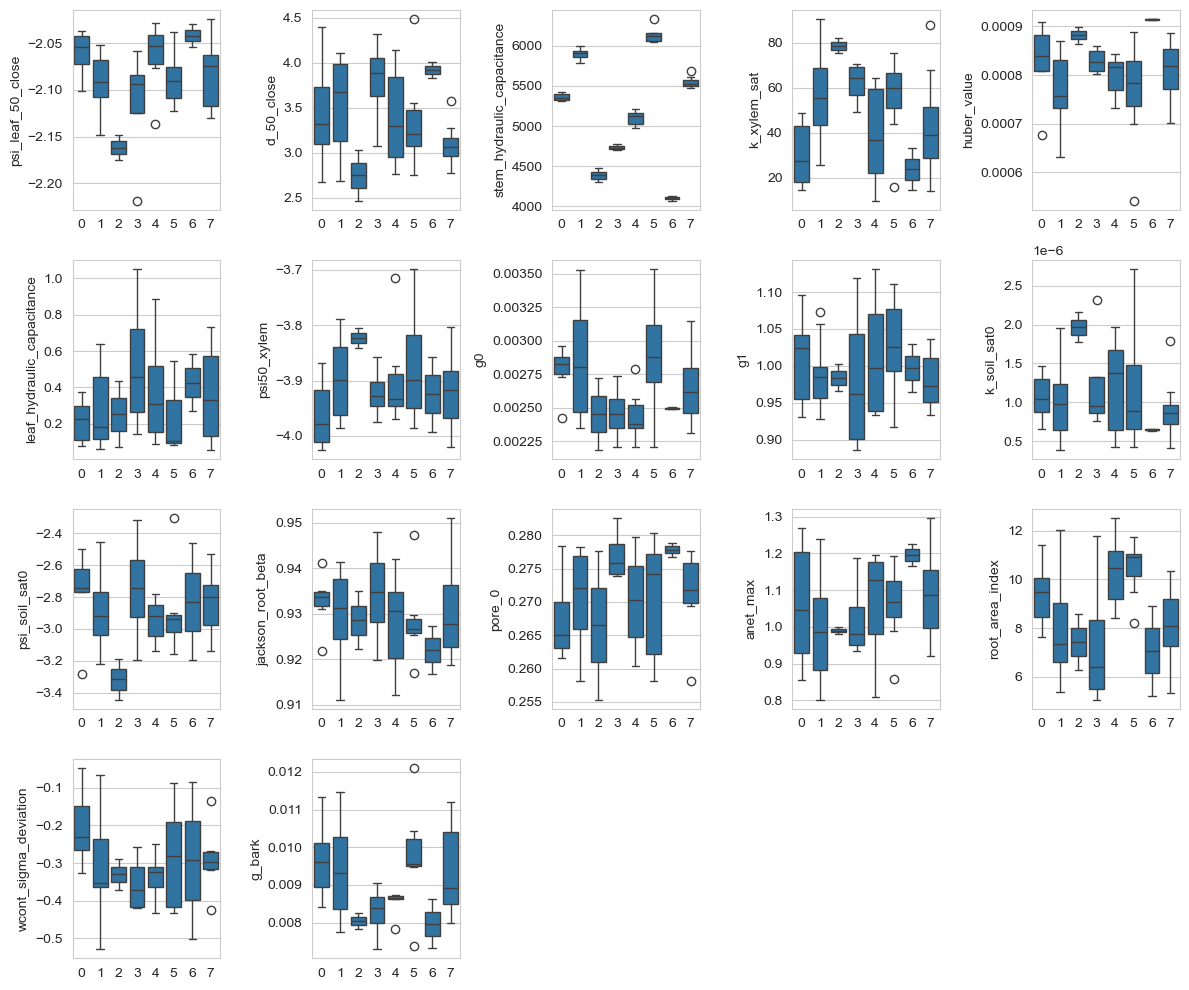

In [20]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars)+1), vars):
    ax = fig.add_subplot(4,5, index)
    sns.boxplot(x = kmeans.labels_, y = df_grp[var], ax=ax)
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()

<Axes: >

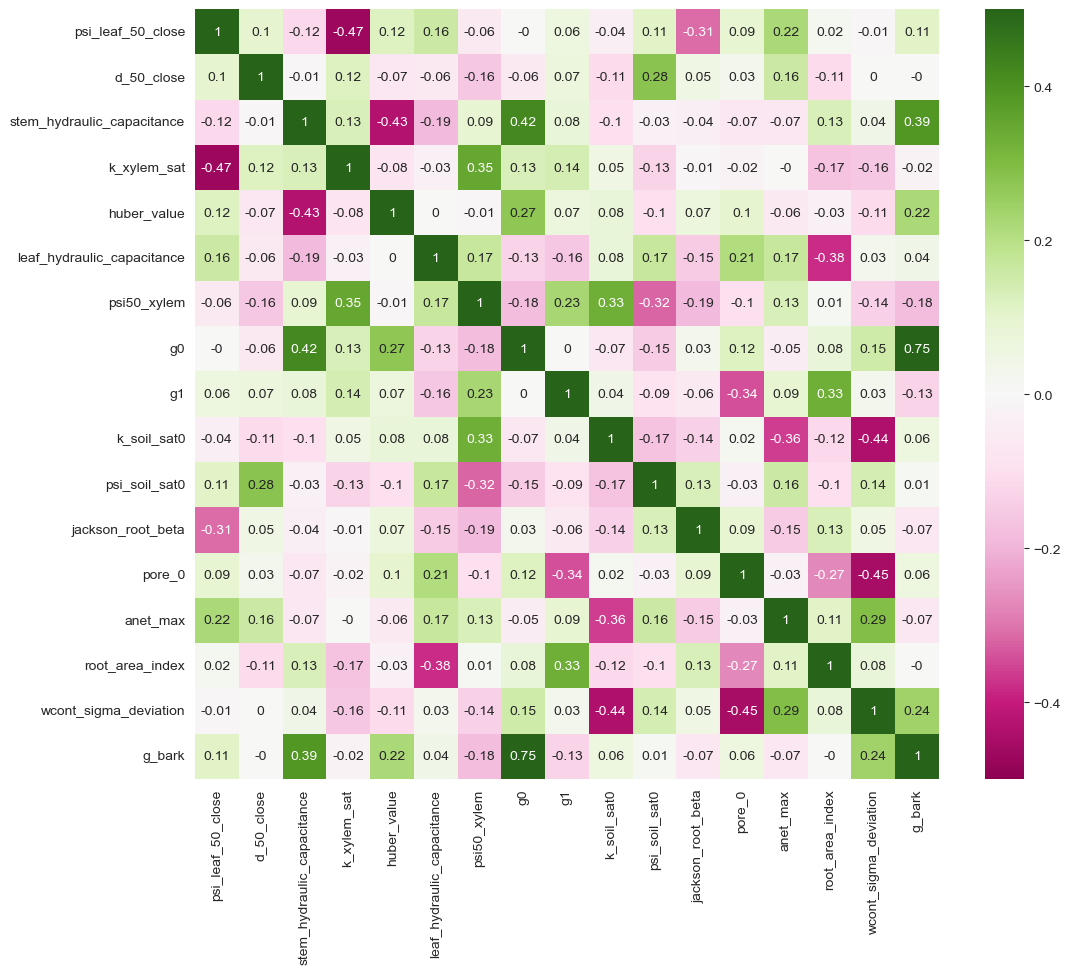

In [21]:
corr_matrix = df_grp.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")

In [119]:
from sklearn.cluster import AgglomerativeClustering
from sklearn import metrics

db = AgglomerativeClustering(n_clusters = 2).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

Estimated number of clusters: 2
Estimated number of noise points: 0
Silhouette Coefficient: 0.079


<Axes: >

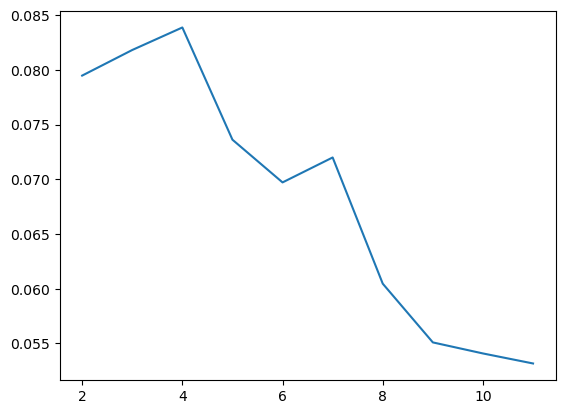

In [124]:
K = range(2, 12)
fits = []
score = []

for k in K:
    # train the model for current value of k on training data
    model = AgglomerativeClustering(n_clusters = k).fit(df_norm[vars_plant])
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(df_norm[vars_plant], model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

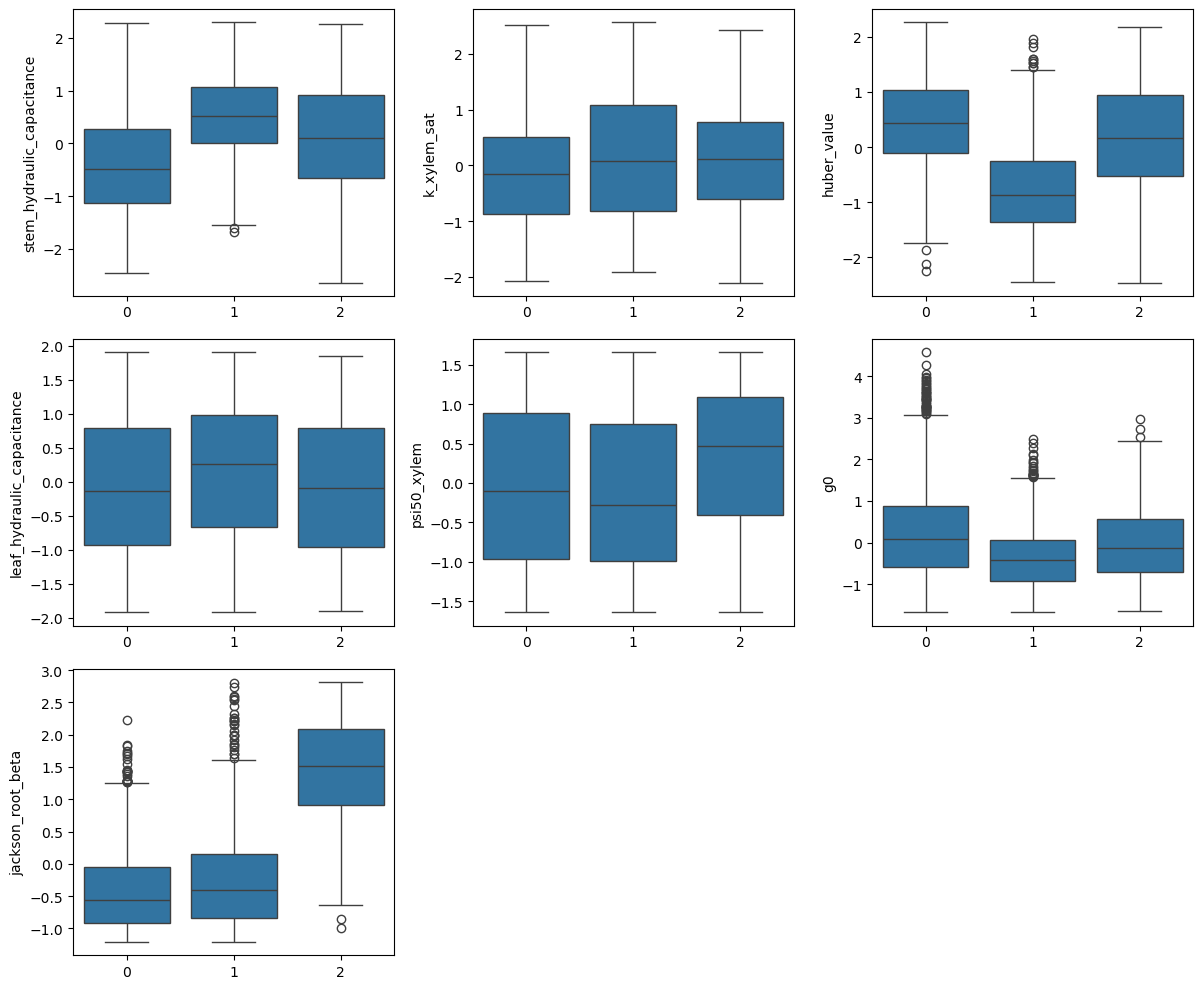

In [123]:
nclusters = 3
db = AgglomerativeClustering(n_clusters=nclusters)
db.fit(df_norm[vars_plant])
cvals = [0.0, 1]
colors = ["red", "tab:blue"]

norm = plt.Normalize(min(cvals), max(cvals))
tuples = list(zip(map(norm, cvals), colors))
import matplotlib.colors

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)
fig = plt.figure(figsize=(12, 10))
for index, var in zip(np.arange(1, len(vars_plant) + 1), vars_plant):
    ax = fig.add_subplot(3, 3, index)
    sns.boxplot(x=db.labels_, y=df_norm[var], ax=ax)
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()

In [125]:
from sklearn.cluster import OPTICS
from sklearn import metrics

db = OPTICS(xi= 0.5).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

Estimated number of clusters: 1
Estimated number of noise points: 0


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [96]:
dv = df[vars]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm=(dv-dv.mean())/dv.std()
df_norm['sid'] = df['sid']

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_38780/3778912720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [13]:
for var in vars:
   #if (var == 'id') | (var == 'sid'):
   #     continue        
    fig = plt.figure(figsize=(10,10))
    for sid in range(1,5):
        dfh = pd.DataFrame()
        dfh[var] = df_norm[df_norm['sid'] == sid][var].values -df_norm[df_norm['sid'] == 0][var].values
        ax = fig.add_subplot(2,2,sid)
        ax.hist(dfh[var], alpha=1.0, bins = 20)
        ax.set_xlabel(var)
        ax.text(0.95, 0.95, f"Mean: {np.round(dfh[var].mean(),4)}",
        verticalalignment ='bottom',
        horizontalalignment ='right',
        transform = ax.transAxes)
    plt.savefig(f"{post_path}/sid_hist_{var}.png")
    plt.close(fig)
        
        

In [14]:
df_norm[vars]

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
4162,0.693507,0.533176,1.923447,-0.367421,-1.450564,-1.447076,0.089589,-0.781660,-0.465101,-0.236377,-0.983641,0.499263,0.525467,-1.047302,0.500996,-0.109707,-0.908170
4160,1.061336,1.097400,1.457328,-0.110994,-1.807826,-1.469186,0.557388,-1.255429,-0.682538,1.314195,0.121878,-0.817452,1.550918,-0.305498,0.085726,1.368923,-0.801305
4163,-0.072881,0.093508,1.370229,-0.185215,-1.630720,-1.305939,1.117320,-0.096612,0.924979,0.000617,-0.178776,0.309975,-1.417684,-1.573092,-0.345383,-0.240577,-0.840873
4164,-0.510443,0.269294,1.158796,0.014388,-1.432004,-1.472270,1.060672,-0.881856,0.572022,-1.277489,-0.496723,-0.524709,-0.079305,-1.287570,0.201675,-0.461661,0.159450
4161,0.462198,0.745553,0.940852,0.058368,-1.504640,-1.555035,-1.642346,-1.012374,0.874660,-0.095744,-1.360155,-0.514166,-0.294040,-1.217969,1.103325,-1.588537,-0.659678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3862,0.539573,-1.189596,-1.315361,0.523803,1.059998,0.891997,-1.063264,1.334101,0.167673,1.056424,-1.216565,1.337206,0.584736,1.321862,0.996734,1.123513,1.240789
3863,0.348079,-1.003476,-1.410635,1.000771,1.224344,0.608916,-0.861625,1.590895,1.061992,-0.105028,-0.754736,2.550748,-0.798448,0.168751,1.527594,0.453394,1.080868
3861,0.532398,-0.365467,-1.555897,1.007842,1.086160,0.962663,0.113190,1.534656,1.332824,0.894390,-0.941756,-0.784218,-0.087222,1.407184,1.576719,0.021158,2.262670
3864,-1.197262,0.151210,-1.307982,0.631991,1.190784,0.901093,-1.439880,1.546110,1.677015,0.148666,0.621578,-0.551654,0.591106,1.452884,0.544589,-0.850802,1.835823


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [16]:
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0
X_train, X_test, y_train, y_test = train_test_split(df_norm[vars_plant], df_norm['alive'], test_size=0.3, random_state=42)


In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2909, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=2909)

In [18]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.8039661898569571
0.7247915087187263


In [358]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [359]:
confusion_matrix(y_test, rf.predict(X_test))

array([[831, 218],
       [145, 125]])

In [360]:
import shap
shap.initjs()

In [361]:
explainer = shap.Explainer(rf)
shap_values = explainer(X_train)

In [362]:
shap.plots.bar(shap_values)

IndexError: list index out of range

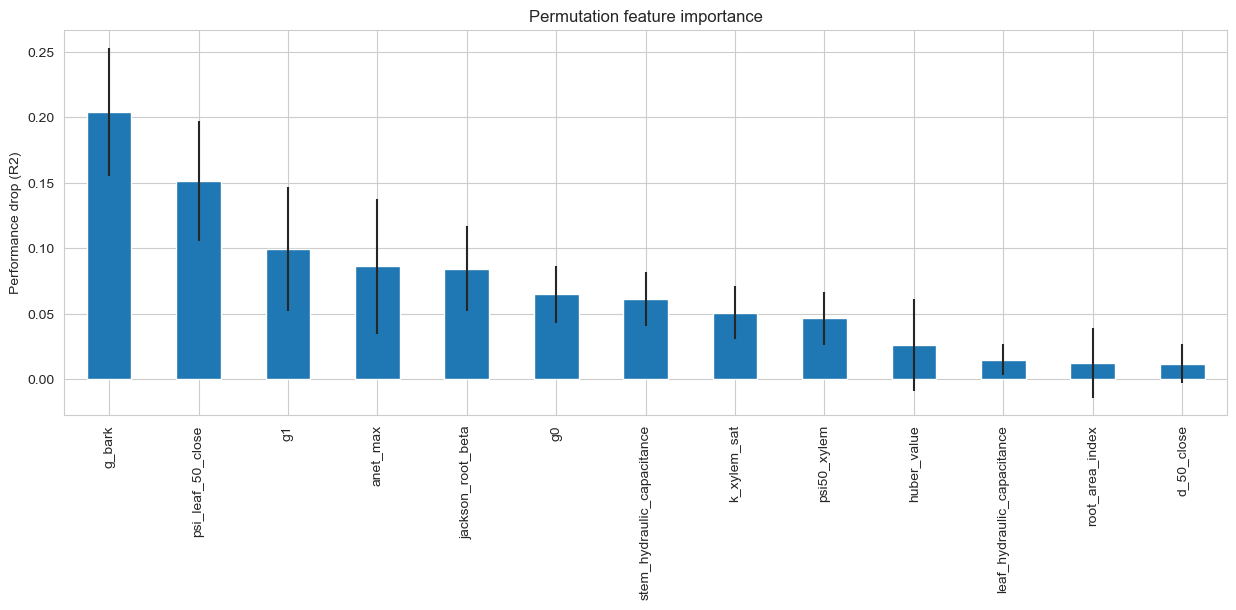

In [363]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,  # we use the test set
    y_test,
    scoring="r2",  # we can use any metric
    n_repeats=100,
    random_state=0,
)
importance = pd.DataFrame(
    {"importance_mean": perm["importances_mean"],
     "importance_std": perm["importances_std"]},
    index=rf.feature_names_in_)
importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()